In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv("Employee  Attrition.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


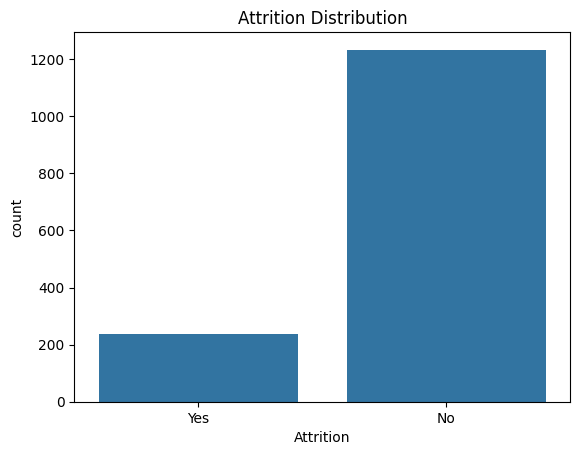

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

In [ ]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['MonthlyIncome'] < lower) |
    (df['MonthlyIncome'] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 114


In [ ]:

import pandas as pd
import numpy as np

df = pd.read_csv("Employee  Attrition.csv")

print(df.shape)
# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

(1470, 35)
Age: 0 outliers
DailyRate: 0 outliers
DistanceFromHome: 0 outliers
Education: 0 outliers
EmployeeCount: 0 outliers
EmployeeNumber: 0 outliers
EnvironmentSatisfaction: 0 outliers
HourlyRate: 0 outliers
JobInvolvement: 0 outliers
JobLevel: 0 outliers
JobSatisfaction: 0 outliers
MonthlyIncome: 114 outliers
MonthlyRate: 0 outliers
NumCompaniesWorked: 52 outliers
PercentSalaryHike: 0 outliers
PerformanceRating: 226 outliers
RelationshipSatisfaction: 0 outliers
StandardHours: 0 outliers
StockOptionLevel: 85 outliers
TotalWorkingYears: 63 outliers
TrainingTimesLastYear: 238 outliers
WorkLifeBalance: 0 outliers
YearsAtCompany: 104 outliers
YearsInCurrentRole: 21 outliers
YearsSinceLastPromotion: 107 outliers
YearsWithCurrManager: 14 outliers


In [ ]:
df_capped = df.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df[col].clip(lower, upper)

In [ ]:

# User Inputs
age = int(input("Enter Age: "))
monthly_income = int(input("Enter Monthly Income: "))
overtime = int(input("Enter Overtime (0/1): "))

# Get feature names
feature_names = df.drop(
    ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'StandardHours'],
    axis=1
).columns

# Create input dataframe
input_data = pd.DataFrame(columns=feature_names)

# Fill all columns with 0
input_data.loc[0] = 0

# Enter values
input_data.loc[0, "Age"] = age
input_data.loc[0, "MonthlyIncome"] = monthly_income

if "OverTime" in input_data.columns:
    input_data.loc[0, "OverTime"] = overtime

# Scale input
scaled_input = scaler.transform(input_data)

# Predict
prediction = model.predict(scaled_input)
probability = model.predict_proba(scaled_input)

print("Prediction:", prediction[0])
print("Stay Probability:", probability[0][0] * 100)
print("Leave Probability:", probability[0][1] * 100)
# Create a copy
df_processed = df.copy()

# Encode Target Variable
df_processed["Attrition"] = df_processed["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# Encode OverTime
df_processed["OverTime"] = df_processed["OverTime"].map({
    "Yes": 1,
    "No": 0
})

# Check Output
print(df_processed.head())

Enter Age: 56
Enter Monthly Income: 10000
Enter Overtime (0/1): 1
Prediction: 1
Stay Probability: 12.734347917164557
Leave Probability: 87.26565208283544
   Age  Attrition  DailyRate  DistanceFromHome  Education  EmployeeCount  \
0   41        NaN       1102                 1          2              1   
1   49        NaN        279                 8          1              1   
2   37        NaN       1373                 2          2              1   
3   33        NaN       1392                 3          4              1   
4   27        NaN        591                 2          1              1   

   EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  ...  \
0               1                        2          94               3  ...   
1               2                        3          61               2  ...   
2               4                        4          92               2  ...   
3               5                        4          56               3  .

In [ ]:
# Features and Target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
X = df.drop([
    'Attrition',
    'EmployeeCount',
    'EmployeeNumber',
    'StandardHours'
], axis=1)

y = df['Attrition']

In [ ]:
print(X.shape)

(1470, 34)


In [3]:


# Encode target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
print(len(X.columns))
print(len(model.coef_[0]))
print(X.shape)

47
44
(1470, 47)


In [ ]:
print(df.columns.tolist())

['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executi

                             Feature  Importance
43              MaritalStatus_Single    0.864567
23              YearsWithCurrManager    0.751247
34           JobRole_Human Resources    0.714756
16                  StockOptionLevel    0.555603
21                YearsInCurrentRole    0.528704
11                NumCompaniesWorked    0.487609
4            EnvironmentSatisfaction    0.481659
40           JobRole_Sales Executive    0.481459
24  BusinessTravel_Travel_Frequently    0.450070
8                    JobSatisfaction    0.419417


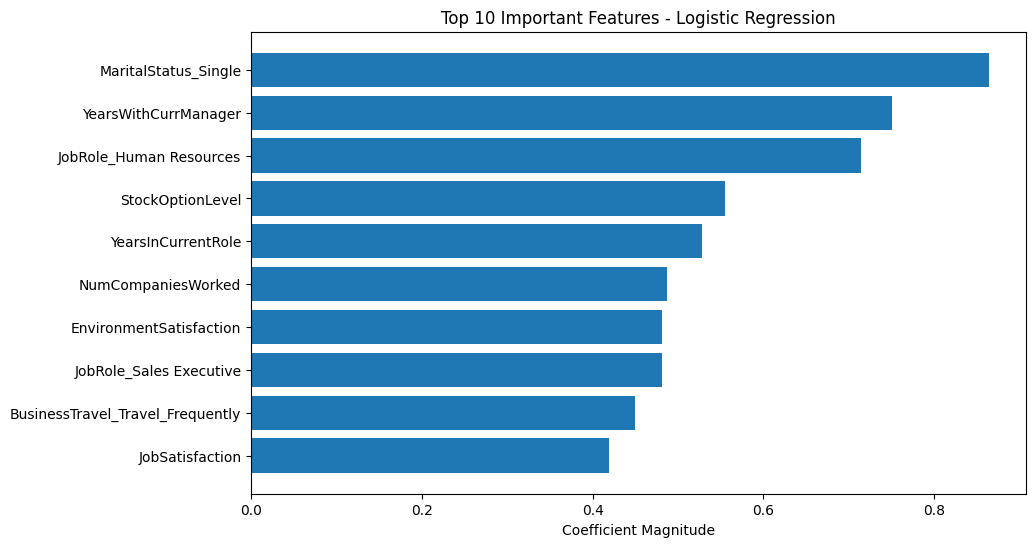

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)

plt.title("Top 10 Important Features - Logistic Regression")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()

plt.show()

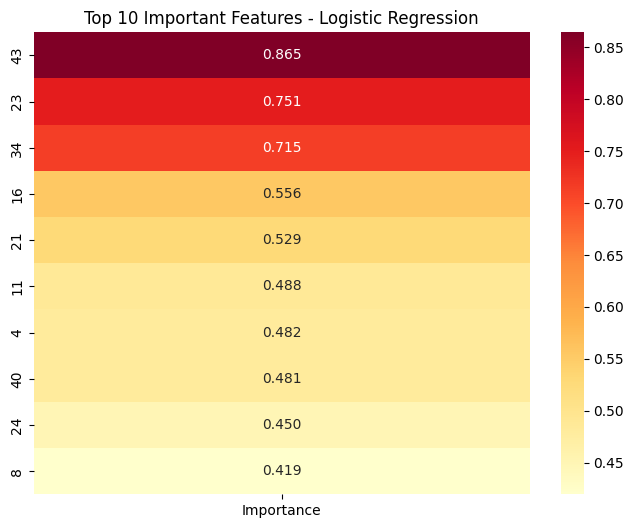

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 important features
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.heatmap(
    top_features[['Importance']],
    annot=True,
    cmap='YlOrRd',
    fmt='.3f'
)

plt.title("Top 10 Important Features - Logistic Regression")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("Employee  Attrition.csv")

# Encode target
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Encode OverTime
df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})

# Encode other categorical columns
df = pd.get_dummies(df, drop_first=True)

# Split data
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:


# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8605442176870748

Confusion Matrix:
[[237  10]
 [ 31  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [ ]:




# Decision Tree Model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334

Confusion Matrix:
[[236  11]
 [ 38   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg       0.80      0.83      0.80       294



In [ ]:


# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train Model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.826530612244898

Confusion Matrix:
[[239   8]
 [ 43   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



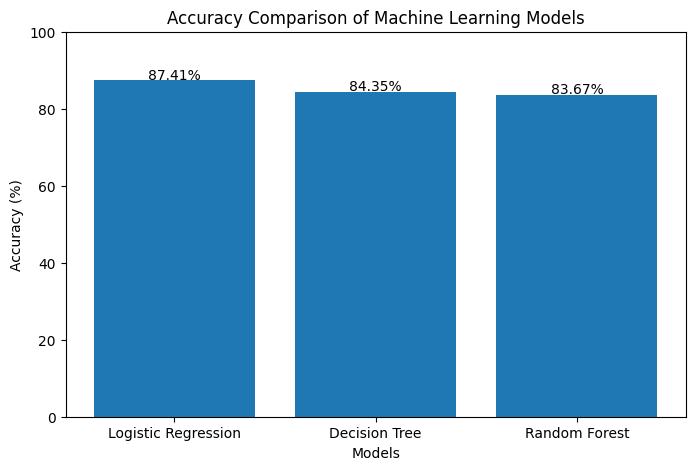

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

# Your accuracies
accuracies = [
    87.41,
    84.35,
    83.67
]

# Plot
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Display values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center')

plt.ylim(0, 100)
plt.show()

In [ ]:
row = int(input(f"Enter employee row number (0-{len(X_test)-1}): "))

employee = X_test[row].reshape(1, -1)

prediction = model.predict(employee)
probability = model.predict_proba(employee)

stay_prob = probability[0][0] * 100
leave_prob = probability[0][1] * 100

print("\n===================================")
print(" EMPLOYEE ATTRITION PREDICTION")
print("===================================")

print(f"\nProbability of Staying : {stay_prob:.2f}%")
print(f"Probability of Leaving : {leave_prob:.2f}%")

if prediction[0] == 1:
    print("\nPrediction : Employee is likely to LEAVE the company.")
else:
    print("\nPrediction : Employee is likely to STAY in the company.")

print("===================================")

Enter employee row number (0-293): 3

 EMPLOYEE ATTRITION PREDICTION

Probability of Staying : 99.36%
Probability of Leaving : 0.64%

Prediction : Employee is likely to STAY in the company.


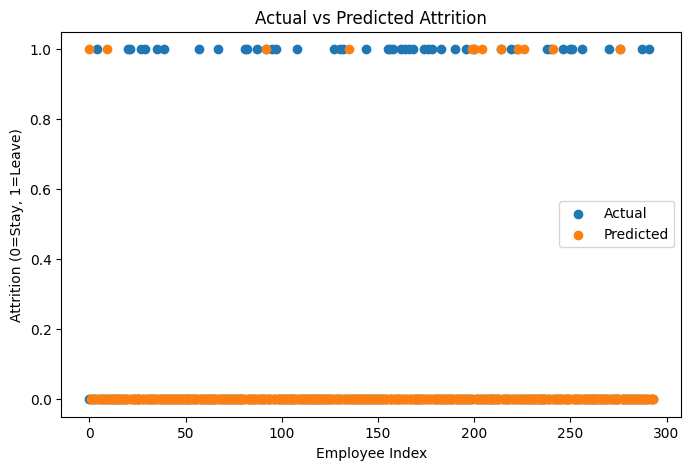

In [ ]:
import matplotlib.pyplot as plt

# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test, label='Actual')
plt.scatter(range(len(y_pred)), y_pred, label='Predicted')

plt.title("Actual vs Predicted Attrition")
plt.xlabel("Employee Index")
plt.ylabel("Attrition (0=Stay, 1=Leave)")

plt.legend()

plt.show()

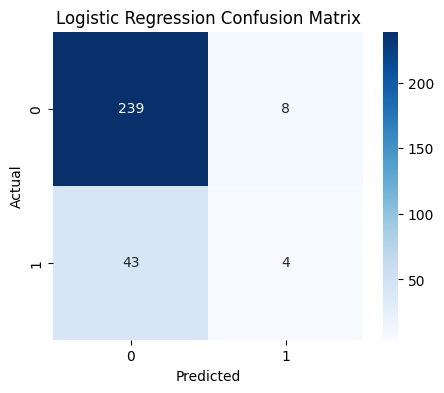

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

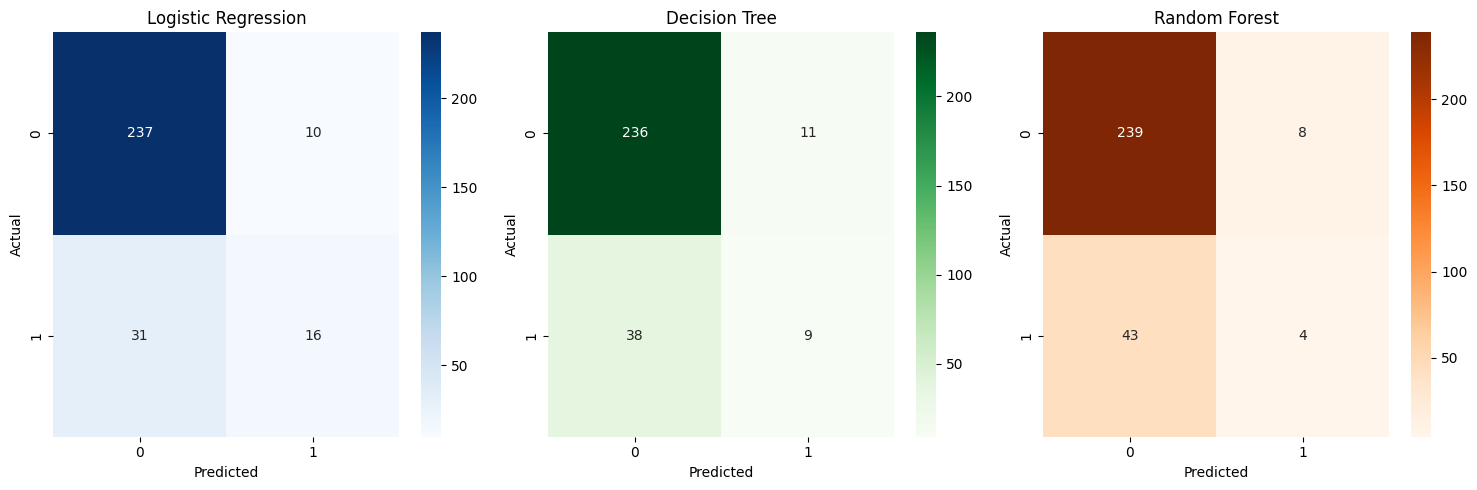

In [ ]:

# Predictions
y_pred_lr = model.predict(X_test)   # Logistic Regression

y_pred_dt = dt.predict(X_test)      # Decision Tree

y_pred_rf = rf.predict(X_test)      # Random Forest

# Confusion Matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Greens',
            ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Oranges',
            ax=axes[2])
axes[2].set_title('Random Forest')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
import pickle

In [ ]:
with open('Employee Attrition_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Pickle file created successfully!")

Pickle file created successfully!


In [ ]:
import pandas as pd

# User Inputs
age = int(input("Enter Age: "))
monthly_income = int(input("Enter Monthly Income: "))
overtime = int(input("Enter Overtime (0/1): "))

# Get feature names
feature_names = df.drop(
    ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'StandardHours'],
    axis=1
).columns

# Create input dataframe
input_data = pd.DataFrame(columns=feature_names)

# Fill all columns with 0
input_data.loc[0] = 0

# Enter values
input_data.loc[0, "Age"] = age
input_data.loc[0, "MonthlyIncome"] = monthly_income

if "OverTime" in input_data.columns:
    input_data.loc[0, "OverTime"] = overtime

# Scale input
scaled_input = scaler.transform(input_data)

# Predict
prediction = model.predict(scaled_input)
probability = model.predict_proba(scaled_input)

print("Prediction:", prediction[0])
print("Stay Probability:", probability[0][0] * 100)
print("Leave Probability:", probability[0][1] * 100)

Enter Age: 41
Enter Monthly Income: 5990
Enter Overtime (0/1): 1
Prediction: 1
Stay Probability: 7.181243408940596
Leave Probability: 92.8187565910594
